In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 1. Features & Target

In [2]:
# Independent and dependent features 
X = df[['tip', 'sex', 'smoker', 'day', 'time', 'size']]
Y = df['total_bill']

df['sex'].value_counts()

sex
Male      157
Female     87
Name: count, dtype: int64

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.25, random_state=10
)
X_train.head()

,tip,sex,smoker,day,time,size
58,1.76,Male,Yes,Sat,Dinner,2
1,1.66,Male,No,Sun,Dinner,3
2,3.50,Male,No,Sun,Dinner,3
68,2.01,Male,No,Sat,Dinner,2
184,3.00,Male,Yes,Sun,Dinner,2


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR

categorical_features = ['sex', 'smoker', 'day', 'time']
numerical_features = ['tip', 'size']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features),
        ('num', StandardScaler(), numerical_features)  # <-- NEW: scaling
    ]
)

# Full pipeline: preprocessing + model, so fit/predict always does both steps consistently
svr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', SVR())
])

In [5]:
svr_pipeline.fit(X_train, Y_train)
y_pred = svr_pipeline.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("Baseline (scaled) SVR results:")
print("R2:", r2_score(Y_test, y_pred))
print("MAE:", mean_absolute_error(Y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, y_pred)))

Baseline (scaled) SVR results:
R2: 0.43694672829778536
MAE: 4.320987701460583
RMSE: 6.904173226719489


## 5. Hyperparameter tuning — wider searcH



In [6]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {
        'regressor__kernel': ['rbf'],
        'regressor__C': [0.1, 1, 10, 100, 1000],
        'regressor__gamma': [1, 0.1, 0.01, 0.001, 0.0001],
        'regressor__epsilon': [0.01, 0.1, 0.5, 1]
    },
    {
        'regressor__kernel': ['linear'],
        'regressor__C': [0.1, 1, 10, 100, 1000],
        'regressor__epsilon': [0.01, 0.1, 0.5, 1]
    },
    {
        'regressor__kernel': ['poly'],
        'regressor__C': [0.1, 1, 10, 100],
        'regressor__degree': [2, 3],
        'regressor__epsilon': [0.01, 0.1, 0.5, 1]
    }
]

grid = GridSearchCV(
    svr_pipeline,
    param_grid,
    refit=True,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, Y_train)

print("Best params:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

Fitting 5 folds for each of 152 candidates, totalling 760 fits


Best params: {'regressor__C': 1, 'regressor__epsilon': 1, 'regressor__kernel': 'linear'}
Best CV R2: 0.5195163445649007


## 6. Evaluate the tuned model on the held-out test set

In [7]:
grid_prediction = grid.predict(X_test)

print("Tuned SVR results:")
print("R2:", r2_score(Y_test, grid_prediction))
print("MAE:", mean_absolute_error(Y_test, grid_prediction))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, grid_prediction)))

Tuned SVR results:
R2: 0.5293390788849699
MAE: 3.9107141304678463
RMSE: 6.312349058965225


## 7. Cross-validated comparison (more reliable than one split)

A single 75/25 split can be lucky or unlucky, especially with only 244 rows. Cross-validating the final model
gives a more trustworthy estimate of how well it generalizes.

In [8]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(grid.best_estimator_, X, Y, cv=5, scoring='r2')
print("5-fold CV R2 scores:", cv_scores)
print("Mean R2:", cv_scores.mean(), "+/-", cv_scores.std())

5-fold CV R2 scores: [0.71410941 0.58815888 0.56587328 0.3905046  0.51805856]
Mean R2: 0.5553409456713869 +/- 0.10483927376688482


## 8. Actual vs. Predicted plot (sanity check)

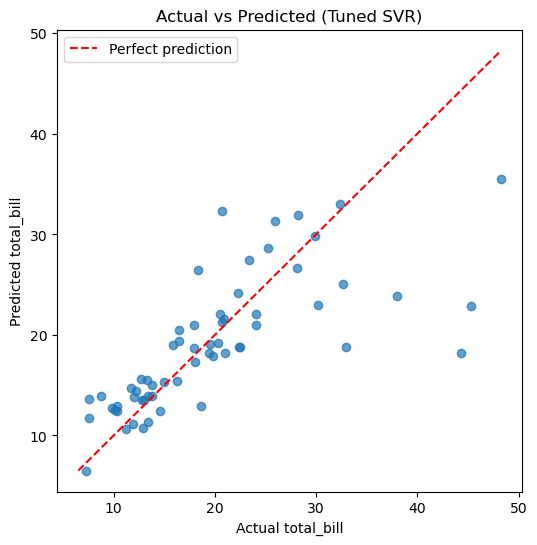

In [9]:
plt.figure(figsize=(6, 6))
plt.scatter(Y_test, grid_prediction, alpha=0.7)
lims = [min(Y_test.min(), grid_prediction.min()), max(Y_test.max(), grid_prediction.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual total_bill')
plt.ylabel('Predicted total_bill')
plt.title('Actual vs Predicted (Tuned SVR)')
plt.legend()
plt.show()